In [4]:
!pip install nlpaug==1.1.11

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.5/410.5 kB 9.7 MB/s eta 0:00:00


In [5]:
# Import libraries
import pandas as pd
import numpy as np
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import re
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, LSTM, Bidirectional, Dense, Dropout, Layer
from tensorflow.keras.callbacks import EarlyStopping
import nlpaug.augmenter.word as naw  # For text augmentation
import os
import requests
import zipfile
from google.colab import drive

dataset --> https://cseweb.ucsd.edu/~jmcauley/datasets/amazon_v2/

In [6]:
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

In [7]:
# Download NLTK resources
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [8]:
from google.colab import drive
import pandas as pd

# Mount Google Drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# Define the path to your CSV file
file_path = '/content/drive/My Drive/Digital_Music_5.json'

In [ ]:
# Read the JSON file with lines=True
try:
    df = pd.read_json(file_path, lines=True)  # Added lines=True for JSON Lines format
    print("JSON file loaded successfully!")
    print(df.head())  # Display first few rows to verify

    # Convert to CSV
    df.to_csv('/content/drive/My Drive/Digital_Music_5.csv', index=False)
    print("Converted to CSV and saved!")
except FileNotFoundError:
    print(f"Error: File not found at {file_path}")
except ValueError as e:
    print(f"Error: Invalid JSON format - {str(e)}")
except Exception as e:
    print(f"An unexpected error occurred: {str(e)}")

JSON file loaded successfully!
   overall  vote  verified   reviewTime      reviewerID        asin  \
0        5   3.0      True   06 3, 2013  A2TYZ821XXK2YZ  3426958910   
1        5   NaN      True  10 11, 2014  A3OFSREZADFUDY  3426958910   
2        5   NaN      True  02 11, 2014  A2VAMODP8M77NG  3426958910   
3        4   3.0     False   12 7, 2013   AAKSLZ9IDTEH0  3426958910   
4        5   NaN      True  06 12, 2016  A3OH43OZJLKI09  5557706259   

                      style       reviewerName  \
0  {'Format:': ' Audio CD'}            Garrett   
1  {'Format:': ' Audio CD'}                 Ad   
2  {'Format:': ' Audio CD'}             JTGabq   
3  {'Format:': ' Audio CD'}  john F&#039;n doe   
4  {'Format:': ' Audio CD'}  melinda a goodman   

                                          reviewText  \
0  This is awesome to listen to, A must-have for ...   
1                                               bien   
2  It was great to hear the old stuff again and I...   
3  well best of's

In [9]:
df = pd.read_csv("/content/drive/My Drive/Digital_Music_5.csv")

In [10]:
print("Dataset Info:")
print(df.info())
print("\nFirst 5 rows:")
print(df.head())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 169781 entries, 0 to 169780
Data columns (total 12 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   overall         169781 non-null  int64  
 1   vote            7611 non-null    float64
 2   verified        169781 non-null  bool   
 3   reviewTime      169781 non-null  object 
 4   reviewerID      169781 non-null  object 
 5   asin            169781 non-null  object 
 6   style           157989 non-null  object 
 7   reviewerName    169763 non-null  object 
 8   reviewText      169613 non-null  object 
 9   summary         169720 non-null  object 
 10  unixReviewTime  169781 non-null  int64  
 11  image           182 non-null     object 
dtypes: bool(1), float64(1), int64(2), object(8)
memory usage: 14.4+ MB
None

First 5 rows:
   overall  vote  verified   reviewTime      reviewerID        asin  \
0        5   3.0      True   06 3, 2013  A2TYZ821XXK2YZ  3426958910 

In [11]:
df.drop(columns=['image'], inplace=True)

In [12]:
df.head()

,overall,vote,verified,reviewTime,reviewerID,asin,style,reviewerName,reviewText,summary,unixReviewTime
0,5,3.0,True,"06 3, 2013",A2TYZ821XXK2YZ,3426958910,{'Format:': ' Audio CD'},Garrett,"This is awesome to listen to, A must-have for ...",Slayer Rules!,1370217600
1,5,NaN,True,"10 11, 2014",A3OFSREZADFUDY,3426958910,{'Format:': ' Audio CD'},Ad,bien,Five Stars,1412985600
2,5,NaN,True,"02 11, 2014",A2VAMODP8M77NG,3426958910,{'Format:': ' Audio CD'},JTGabq,It was great to hear the old stuff again and I...,SLAYER!!!!!!!!!!!!!!!!!!!!!,1392076800
3,4,3.0,False,"12 7, 2013",AAKSLZ9IDTEH0,3426958910,{'Format:': ' Audio CD'},john F&#039;n doe,well best of's are a bit poison normally but t...,slayer greatest hits! you mean everything righ...,1386374400
4,5,NaN,True,"06 12, 2016",A3OH43OZJLKI09,5557706259,{'Format:': ' Audio CD'},melinda a goodman,What can I say? This is Casting Crowns!!!This ...,"This is a good, blessing filled",1465689600


In [13]:
df.shape

(169781, 11)

In [14]:
# Clean dataset
df = df[['overall', 'reviewText']].dropna()
print(f"\nDataset size after cleaning: {df.shape}")


Dataset size after cleaning: (169613, 2)


In [15]:
# Binary sentiment: 1-3 = Negative (0), 4-5 = Positive (1)
df['sentiment'] = df['overall'].apply(lambda x: 1 if x >= 4 else 0)
print("\nSentiment distribution (before balancing):")
print(df['sentiment'].value_counts())


Sentiment distribution (before balancing):
sentiment
1    158825
0     10788
Name: count, dtype: int64


In [16]:
# Advanced preprocessing
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

In [17]:
def preprocess_text(text):
    """Advanced preprocessing: lowercase, clean, tokenize, lemmatize, remove stopwords."""
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words and len(word) > 2]
    return ' '.join(tokens)

In [18]:
df['cleaned_text'] = df['reviewText'].apply(preprocess_text)
print("\nSample of cleaned text:")
print(df[['reviewText', 'cleaned_text']].head())


Sample of cleaned text:
                                          reviewText  \
0  This is awesome to listen to, A must-have for ...   
1                                               bien   
2  It was great to hear the old stuff again and I...   
3  well best of's are a bit poison normally but t...   
4  What can I say? This is Casting Crowns!!!This ...   

                                        cleaned_text  
0  awesome listen musthave slayer fanssadly neede...  
1                                               bien  
2  great hear old stuff like new stuff recommend ...  
3  well best ofs bit poison normally bad pretty g...  
4        say casting crownsthis good blessing filled  


In [19]:
df[['reviewText', 'cleaned_text']].head()

,reviewText,cleaned_text
0,"This is awesome to listen to, A must-have for ...",awesome listen musthave slayer fanssadly neede...
1,bien,bien
2,It was great to hear the old stuff again and I...,great hear old stuff like new stuff recommend ...
3,well best of's are a bit poison normally but t...,well best ofs bit poison normally bad pretty g...
4,What can I say? This is Casting Crowns!!!This ...,say casting crownsthis good blessing filled


In [20]:
# Data augmentation with nlpaug (synonym replacement)
aug = naw.SynonymAug(aug_p=0.3)  # 30% chance to replace words with synonyms
df_aug = df.copy()

In [21]:
def safe_augment(text):
    """Safely augment text, handling empty or invalid outputs."""
    if not text or len(text.strip()) == 0:  # Check for empty input
        return text
    augmented = aug.augment(text)
    # Handle both list and string outputs from augment()
    if isinstance(augmented, list):
        return augmented[0] if augmented else text  # Return first item or original if empty
    return augmented  # Return s

In [22]:
df_aug['cleaned_text'] = df_aug['cleaned_text'].apply(safe_augment)
df = pd.concat([df, df_aug], ignore_index=True)  # Double dataset size with augmented data
print(f"\nDataset size after augmentation: {df.shape}")


Dataset size after augmentation: (339226, 4)


In [23]:
# Tokenization and padding
max_words = 20000  # Larger vocab for richer representation
max_len = 200      # Longer sequences for more context
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(df['cleaned_text'])
sequences = tokenizer.texts_to_sequences(df['cleaned_text'])
X = pad_sequences(sequences, maxlen=max_len)
y = df['sentiment'].values

In [24]:
# Balance classes with SMOTE
smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X, y)
print(f"\nBalanced dataset size: {X_balanced.shape}, Sentiment distribution: {np.bincount(y_balanced)}")


Balanced dataset size: (635300, 200), Sentiment distribution: [317650 317650]


In [25]:
# Split into train, val, test
X_temp, X_test, y_temp, y_test = train_test_split(X_balanced, y_balanced, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)
print(f"Train: {X_train.shape}, Validation: {X_val.shape}, Test: {X_test.shape}")

Train: (381180, 200), Validation: (127060, 200), Test: (127060, 200)


In [26]:
# Load GloVe 100d embeddings (download if not in Drive)
glove_path = '/content/drive/My Drive/glove.6B.100d.txt'
embedding_dim = 100  # Changed to 100d
embedding_index = {}

In [27]:
if not os.path.exists(glove_path):
    print(f"GloVe file not found at {glove_path}. Downloading...")
    url = 'http://nlp.stanford.edu/data/glove.6B.zip'
    glove_zip_path = '/content/glove.6B.zip'
    response = requests.get(url)
    with open(glove_zip_path, 'wb') as f:
        f.write(response.content)
    with zipfile.ZipFile(glove_zip_path, 'r') as zip_ref:
        zip_ref.extract('glove.6B.100d.txt', '/content')
    glove_path = '/content/glove.6B.100d.txt'
    print("GloVe file downloaded and extracted.")

GloVe file not found at /content/drive/My Drive/glove.6B.100d.txt. Downloading...
GloVe file downloaded and extracted.


In [28]:
print("Loading GloVe 100d embeddings...")
with open(glove_path, 'r', encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embedding_index[word] = coefs

Loading GloVe 100d embeddings...


In [29]:
# Create embedding matrix
word_index = tokenizer.word_index
embedding_matrix = np.zeros((max_words, embedding_dim))
for word, i in word_index.items():
    if i < max_words:
        embedding_vector = embedding_index.get(word)
        if embedding_vector is not None:
            embedding_matrix[i] = embedding_vector
print(f"Embedding matrix shape: {embedding_matrix.shape}")

Embedding matrix shape: (20000, 100)


#DEEP LEARNING MODEL IMPLEMENTATION

#### Goal: Advanced Bidirectional LSTM with custom Attention, manual hyperparameter tuning, gradient clipping



In [31]:
# Define custom Attention layer
class CustomAttention(Layer):
    def __init__(self, **kwargs):
        super(CustomAttention, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(name='attention_weight', shape=(input_shape[-1], 1),
                                 initializer='random_normal', trainable=True)
        self.b = self.add_weight(name='attention_bias', shape=(input_shape[1], 1),
                                 initializer='zeros', trainable=True)
        super(CustomAttention, self).build(input_shape)

    def call(self, inputs):
        # Attention mechanism: e = tanh(W * h + b), alpha = softmax(e)
        e = tf.tanh(tf.tensordot(inputs, self.W, axes=1) + self.b)
        alpha = tf.nn.softmax(e, axis=1)
        context = inputs * alpha
        return tf.reduce_sum(context, axis=1)

In [32]:
# Define model function
def create_model(lstm_units=128, dropout_rate=0.5):
    """Create Bidirectional LSTM with custom Attention."""
    inputs = Input(shape=(max_len,))
    x = Embedding(max_words, embedding_dim, weights=[embedding_matrix], trainable=False)(inputs)
    x = Bidirectional(LSTM(lstm_units, return_sequences=True))(x)
    x = CustomAttention()(x)
    x = Dropout(dropout_rate)(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(dropout_rate)(x)
    outputs = Dense(1, activation='sigmoid')(x)
    model = Model(inputs, outputs)
    optimizer = tf.keras.optimizers.Adam(clipnorm=1.0)  # Gradient clipping
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    return model

In [33]:
# Manual hyperparameter tuning with k-fold CV
param_candidates = [
    {'lstm_units': 64, 'dropout_rate': 0.3},
    {'lstm_units': 128, 'dropout_rate': 0.3},
    {'lstm_units': 64, 'dropout_rate': 0.5},
    {'lstm_units': 128, 'dropout_rate': 0.5}
]
kfold = KFold(n_splits=3, shuffle=True, random_state=42)
best_score = 0
best_params = None

In [34]:
print("\nPerforming 3-fold CV for hyperparameter tuning (optimized for speed)...")
for param_idx, params in enumerate(param_candidates, 1):
    print(f"\nEvaluating Parameter Set {param_idx}/{len(param_candidates)}: {params}")
    fold_scores = []
    for fold_idx, (train_idx, val_idx) in enumerate(kfold.split(X_train), 1):
        print(f"  Fold {fold_idx}/3 starting...")
        X_fold_train, X_fold_val = X_train[train_idx], X_train[val_idx]
        y_fold_train, y_fold_val = y_train[train_idx], y_train[val_idx]
        model = create_model(**params)
        print(f"    Training model with {len(X_fold_train)} samples...")
        model.fit(X_fold_train, y_fold_train, epochs=2, batch_size=64, verbose=1,  # Reduced epochs, increased batch size
                  validation_data=(X_fold_val, y_fold_val),
                  callbacks=[EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)])
        score = model.evaluate(X_fold_val, y_fold_val, verbose=0)[1]  # Accuracy
        fold_scores.append(score)
        print(f"  Fold {fold_idx}/3 completed. Validation Accuracy: {score:.4f}")
    avg_score = np.mean(fold_scores)
    print(f"Parameter Set {param_idx} completed. Average CV Accuracy: {avg_score:.4f}")
    if avg_score > best_score:
        best_score = avg_score
        best_params = params

print(f"\nBest Params: {best_params}, Best CV Accuracy: {best_score:.4f}")


Performing 3-fold CV for hyperparameter tuning (optimized for speed)...

Evaluating Parameter Set 1/4: {'lstm_units': 64, 'dropout_rate': 0.3}
  Fold 1/3 starting...
    Training model with 254120 samples...
Epoch 1/2
3971/3971 ━━━━━━━━━━━━━━━━━━━━ 108s 25ms/step - accuracy: 0.7351 - loss: 0.5132 - val_accuracy: 0.8219 - val_loss: 0.3886
Epoch 2/2
3971/3971 ━━━━━━━━━━━━━━━━━━━━ 136s 25ms/step - accuracy: 0.8459 - loss: 0.3453 - val_accuracy: 0.8574 - val_loss: 0.3228
  Fold 1/3 completed. Validation Accuracy: 0.8574
  Fold 2/3 starting...
    Training model with 254120 samples...
Epoch 1/2
3971/3971 ━━━━━━━━━━━━━━━━━━━━ 103s 25ms/step - accuracy: 0.7343 - loss: 0.5202 - val_accuracy: 0.8400 - val_loss: 0.3536
Epoch 2/2
3971/3971 ━━━━━━━━━━━━━━━━━━━━ 142s 25ms/step - accuracy: 0.8459 - loss: 0.3484 - val_accuracy: 0.8563 - val_loss: 0.3226
  Fold 2/3 completed. Validation Accuracy: 0.8563
  Fold 3/3 starting...
    Training model with 254120 samples...
Epoch 1/2
3971/3971 ━━━━━━━━━━━━━

In [36]:
# Train final model with real-time progress
final_model = create_model(**best_params)
print("\nTraining final model with best parameters...")
history = final_model.fit(X_train, y_train, epochs=3, batch_size=64, verbose=1,  # Match batch size, keep verbose
                          validation_data=(X_val, y_val),
                          callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)])
print("\nFinal Model Summary:")
final_model.summary()


Training final model with best parameters...
Epoch 1/3
5956/5956 ━━━━━━━━━━━━━━━━━━━━ 171s 28ms/step - accuracy: 0.7349 - loss: 0.5115 - val_accuracy: 0.8472 - val_loss: 0.3378
Epoch 2/3
5956/5956 ━━━━━━━━━━━━━━━━━━━━ 168s 28ms/step - accuracy: 0.8542 - loss: 0.3279 - val_accuracy: 0.8660 - val_loss: 0.3024
Epoch 3/3
5956/5956 ━━━━━━━━━━━━━━━━━━━━ 170s 28ms/step - accuracy: 0.8824 - loss: 0.2733 - val_accuracy: 0.8791 - val_loss: 0.2751

Final Model Summary:


Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_13 (InputLayer)          │ (None, 200)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ embedding_13 (Embedding)             │ (None, 200, 100)            │       2,000,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_13 (Bidirectional)     │ (None, 200, 256)            │         234,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ custom_attention_13                  │ (None, 256)                 │             456 │
│ (CustomAttention)                    │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_26 (Dropout)                 │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_26 (Dense)                     │ (None, 64)                  │          16,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_27 (Dropout)                 │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_27 (Dense)                     │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,754,397 (10.51 MB)

 Trainable params: 251,465 (982.29 KB)

 Non-trainable params: 2,000,000 (7.63 MB)

 Optimizer params: 502,932 (1.92 MB)

In [37]:
# Predict on test set
y_pred_prob = final_model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

3971/3971 ━━━━━━━━━━━━━━━━━━━━ 30s 7ms/step


# **Evaluations**

In [38]:
# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print("\nTest Set Evaluation Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")


Test Set Evaluation Metrics:
Accuracy: 0.8790
Precision: 0.8406
Recall: 0.9345
F1-Score: 0.8851


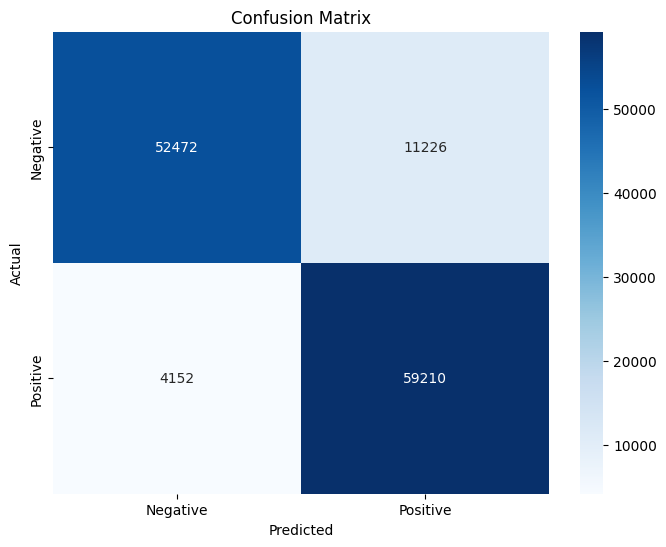

In [39]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

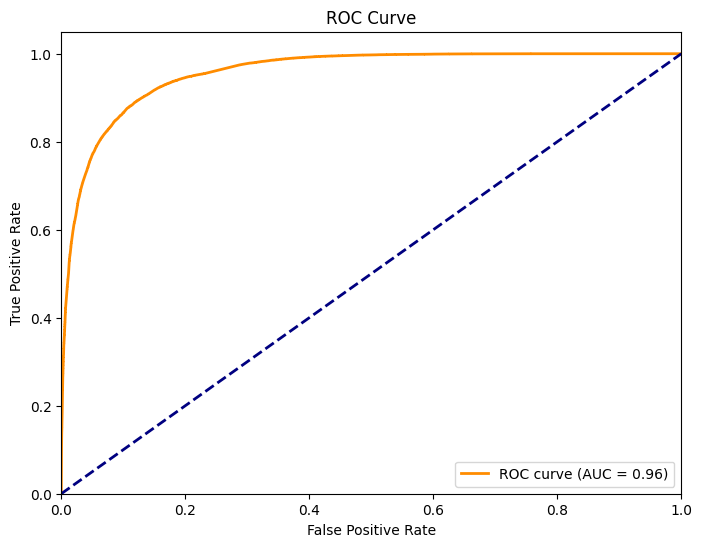

In [40]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()

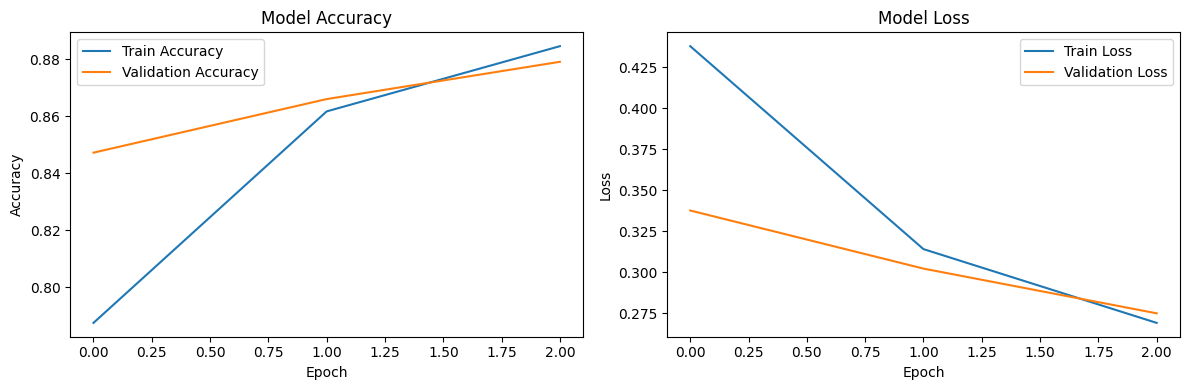

In [41]:
# Learning Curves
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

In [2]:
# Insights
print("\nInsights:")
print("Strengths:")
print("- Data augmentation and SMOTE ensure robust, balanced training data.")
print("- Bidirectional LSTM with custom Attention captures nuanced sentiment.")
print("- Gradient clipping and k-fold CV enhance training stability and reliability.")
print("Limitations:")
print("- High computational cost due to Bidirectional LSTM and augmentation.")
print("- Synthetic data (SMOTE, augmentation) may introduce subtle biases.")
print("Improvements:")
print("- Use contextual embeddings (e.g., BERT) for even better performance.")
print("- Implement ensemble methods for improved robustness.")
print("- Optimize max_len dynamically based on review length distribution.")


Insights:
Strengths:
- Data augmentation and SMOTE ensure robust, balanced training data.
- Bidirectional LSTM with custom Attention captures nuanced sentiment.
- Gradient clipping and k-fold CV enhance training stability and reliability.
Limitations:
- High computational cost due to Bidirectional LSTM and augmentation.
- Synthetic data (SMOTE, augmentation) may introduce subtle biases.
Improvements:
- Use contextual embeddings (e.g., BERT) for even better performance.
- Implement ensemble methods for improved robustness.
- Optimize max_len dynamically based on review length distribution.
